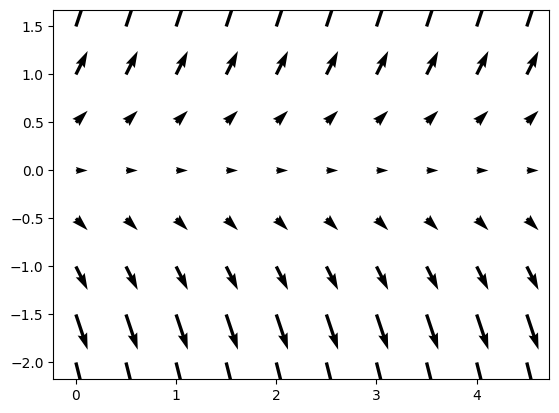

In [1]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(0, 5, 0.5)
y = np.arange(-2, 2, 0.5)
X, Y = np.meshgrid(x, y)

U = np.ones(X.shape)
V = 2*Y

fig, ax = plt.subplots()
q = ax.quiver(X, Y, U, V)
ax.quiverkey(q, X=0.3, Y=1.1, U=10,
             label='Quiver key, length = 10', labelpos='E')

plt.show()

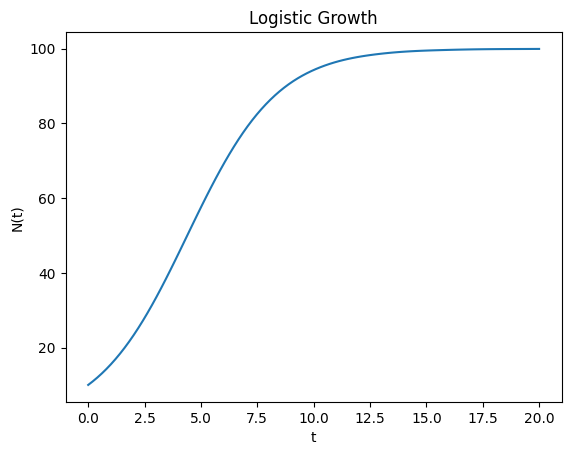

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import ipywidgets as widgets

r = 0.5
K = 100

def f(t, N):
    return r*N*(1-(N/K))
 
t_span = (0, 20)
N0 = [10]
 
sol = solve_ivp(f, t_span, N0, t_eval=np.linspace(0, 20, 100))
 
plt.plot(sol.t, sol.y[0])
plt.xlabel('t')
plt.ylabel('N(t)')
plt.title('Logistic Growth')
plt.show()



In [3]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import ipywidgets as widgets
from IPython.display import display

dt = 1e-3
t = np.arange(0,100,dt)
#N_sol = [0] #N_0 initial population
N = np.linspace(-10,200,100)

def dNdt(N,r,K,h):
    """
    Return the logisitc growth differential function for population size N with intrinsic growth rate r and carrying capacity K.
    """
    return (r*N*(1-(N/K)))-h

plt.ioff()  # stop the figure from auto-displaying when created

# set up plot
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(10,5))
ax1.set_ylim([-10,50])
ax1.set_xlim([-10,200])
ax1.grid(True)
ax1.set_xlabel('Population size (N)')
ax1.set_ylabel('Population Growth Rate (dN/dt)')
ax1.set_title('Phase-line Diagram')

ax2.set_ylim([-10,50])
ax2.set_xlim([-10,200])
ax2.grid(True)
ax2.set_xlabel('Time')
ax2.set_ylabel('Population Size (N)')
ax2.set_title('Population Growth function')

fig.suptitle('Logistic Growth with Harvesting')

@widgets.interact(r=(0,1,0.1), K=(0.1,100,1), h=(0,200,1), N0 = (0,200,1))
def update(r = 1, K = 100, h = 0, N0 = 10):
    
    """Remove old lines from plot and plot new one"""
    [l.remove() for l in ax1.lines]
    [l.remove() for l in ax2.lines]

    N_sol = [N0]
    
    for i in range(len(t)-1):
        N_sol.append(N_sol[i]+dt*dNdt(N_sol[i],r,K,h)) #Forward-Euler
    
    ax1.plot(N, dNdt(N,r,K,h), color = 'C0')
    ax2.plot(t, N_sol, color = 'r')
    display(fig)

interactive(children=(FloatSlider(value=1.0, description='r', max=1.0), FloatSlider(value=100.0, description='…

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import ipywidgets as widgets
from IPython.display import display

dt = 1e-3
t = np.arange(0,100,dt)
#N_sol = [0] #N_0 initial population
N = np.linspace(-10,200,100)

def dNdt(N,r,K,h):
    """
    Return the logisitc growth differential function for population size N with intrinsic growth rate r and carrying capacity K.
    """
    return (r*N*(1-(N/K)))-(h*N)

plt.ioff()  # stop the figure from auto-displaying when created

# set up plot
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(10,5))
# ax1.set_ylim([-10,50])
# ax1.set_xlim([-10,200])
ax1.grid(True)
ax1.set_xlabel('Population size (N)')
ax1.set_ylabel('Population Growth Rate (dN/dt)')
ax1.set_title('Phase-line Diagram')

# ax2.set_ylim([0,50])
# ax2.set_xlim([0,200])
ax2.grid(True)
ax2.set_xlabel('Time')
ax2.set_ylabel('Population Size (N)')
ax2.set_title('Population Growth function')

fig.suptitle('Logistic Growth with Harvesting')

@widgets.interact(har_func = ["Constant Harvesting", "Variable Harvesting", "Harvesting with Restocking"])
def choose_harvest_func(har_func):
    print(f'Choose the harvest function {har_func}')
    
@widgets.interact(r=(0,1,0.1), K=(0.1,100,1), h=(0,1,0.1), N0 = (0,200,1))
def update(r = 1, K = 100, h = 0, N0 = 10):
    
    """Remove old lines from plot and plot new one"""
    [l.remove() for l in ax1.lines]
    [l.remove() for l in ax2.lines]

    N_sol = [N0]
    N_sol_h0 = [N0]
    
    for i in range(len(t)-1):
        N_sol.append(N_sol[i]+dt*dNdt(N_sol[i],r,K,h)) #Forward-Euler
        N_sol_h0.append(N_sol_h0[i]+dt*dNdt(N_sol[i],r,K,0)) #Forward-Euler
    ax1.set_ylim([-10,50])
    ax1.set_xlim([-10,200])

    #ax2.set_ylim([-10,1.5*K])
    #ax2.set_xlim([-10,200])
    
    ax1.plot(N, dNdt(N,r,K,h), 'b')
    ax1.plot(N, dNdt(N,r,K,0), 'c--')
    ax2.plot(t, N_sol, 'r')
    ax2.plot(t, N_sol_h0, 'c--')
    display(fig)

interactive(children=(Dropdown(description='har_func', options=('Constant Harvesting', 'Variable Harvesting', …

interactive(children=(FloatSlider(value=1.0, description='r', max=1.0), FloatSlider(value=100.0, description='…

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import ipywidgets as widgets
from IPython.display import display

dt = 1e-3
t = np.arange(0,100,dt)
#N_sol = [0] #N_0 initial population
N = np.linspace(-10,200,100)
h_max= 0

# def dNdt(N,r,K,h):
#     """
#     Return the logisitc growth differential function for population size N with intrinsic growth rate r and carrying capacity K.
#     """
#     if har_func == "Constant Harvesting":
#         return (r*N*(1-(N/K)))-h

#     elif har_func == "Variable Harvesting":
#         return (r*N*(1-(N/K)))-h*N
#     # else:
#     #     return (r*N*(1-(N/K)))-h*math.sin(w*t)
        

# def H(w,t,N):
#     """
#     Return the harvest function, based on how it's related to the population size.
#     """
    

plt.ioff()  # stop the figure from auto-displaying when created

# set up plot
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(10,5))
# ax1.set_ylim([-10,50])
# ax1.set_xlim([-10,200])
ax1.grid(True)
ax1.set_xlabel('Population size (N)')
ax1.set_ylabel('Population Growth Rate (dN/dt)')
ax1.set_title('Phase-line Diagram')

# ax2.set_ylim([0,50])
# ax2.set_xlim([0,200])
ax2.grid(True)
ax2.set_xlabel('Time')
ax2.set_ylabel('Population Size (N)')
ax2.set_title('Population Growth function')

fig.suptitle('Logistic Growth with Harvesting')

def update(har_func = "Constant Harvesting", r = 1, K = 100, h = 0, N0 = 10):
    
    """Remove old lines from plot and plot new one"""
    [l.remove() for l in ax1.lines]
    [l.remove() for l in ax2.lines]

    def dNdt(N,r,K,h):
    
        if har_func == "Constant Harvesting":
            return (r*N*(1-(N/K)))-h
    
        elif har_func == "Variable Harvesting":
            return (r*N*(1-(N/K)))-h*N
        # else:
        #     return (r*N*(1-(N/K)))-h*math.sin(w*t)
    

    N_sol = [N0]
    
    for i in range(len(t)-1):
        N_sol.append(N_sol[i]+dt*dNdt(N_sol[i],r,K,h)) #Forward-Euler

    ax1.set_ylim([-10,50])
    ax1.set_xlim([-10,200])

    #ax2.set_ylim([-10,1.5*K])
    #ax2.set_xlim([-10,200])

    
    ax1.plot(N, dNdt(N,r,K,h), color = 'b')
    ax1.plot(N, dNdt(N,r,K,0), 'c--')
    ax2.plot(t, N_sol, color = 'r')
    display(fig)

widgets.interact(
    update, 
    har_func = ["Constant Harvesting", "Variable Harvesting", "Harvesting with Restocking"],
    r=(0,1,0.1), 
    K=(0.1,100,1), 
    h=(0,1,0.1), 
    N0 = (0,200,1),
)



interactive(children=(Dropdown(description='har_func', options=('Constant Harvesting', 'Variable Harvesting', …

<function __main__.update(har_func='Constant Harvesting', r=1, K=100, h=0, N0=10)>

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import ipywidgets as widgets
from IPython.display import display

dt = 1e-3
t_sol = np.arange(0,100,dt)
#N_sol = [0] #N_0 initial population
#N = np.linspace(-10,200,100)
h_max= 0

#logistic growth function
def Log(N,r,K):
    """
    Return the logisitc growth function for population size N with intrinsic growth rate r and carrying capacity K.
    """
    return r*N*(1-(N/K))

#Harvesting rate function
def H(N,h): #H(t,N,w):
    """
    Return the harvest function, based on how it's related to the population size.
    """
    if har_func == "Constant Harvesting":
        return h

    elif har_func == "Variable Harvesting":
        return h*N
    # else:
    #     return h*math.sin(w*t) 
        
#differential equation combining Logistic & different Harvest functions
def dNdt(N,r,K,h):
    """
    Return the differential equation combining Logistic & different Harvest functions.
    """
    return Log(N,r,K)-H(N,h)



plt.ioff()  # stop the figure from auto-displaying when created

# set up plot
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(10,5))
# ax1.set_ylim([-10,50])
# ax1.set_xlim([-10,200])
ax1.grid(True)
ax1.set_xlabel('Population size (N)')
ax1.set_ylabel('Population Growth Rate (dN/dt)')
ax1.set_title('Phase-line Diagram')

# ax2.set_ylim([0,50])
# ax2.set_xlim([0,200])
ax2.grid(True)
ax2.set_xlabel('Time')
ax2.set_ylabel('Population Size (N)')
ax2.set_title('Population Growth function')

fig.suptitle('Logistic Growth with Harvesting')

def update(har_func = "Constant Harvesting", r = 1, K = 100, h = 0, N0 = 10):
    
    """Remove old lines from plot and plot new one"""
    [l.remove() for l in ax1.lines]
    [l.remove() for l in ax2.lines]
    

    N_sol = [N0]
    
    for i in range(len(t_sol)-1):
        N_sol.append(N_sol[i]+dt*dNdt(N_sol[i],r,K,h)) #Forward-Euler

    ax1.set_ylim([-10,50])
    ax1.set_xlim([-10,200])

    #ax2.set_ylim([-10,1.5*K])
    #ax2.set_xlim([-10,200])

    
    ax1.plot(N_sol, dNdt(N_sol,r,K,H), color = 'b')
    ax1.plot(N_sol, dNdt(N_sol,r,K,0), 'c--')
    ax2.plot(t_sol, N_sol, color = 'r')
    display(fig)

#Widgets:

r_val = widgets

radiobuttons = widgets.RadioButtons(
    value='Logistic w/ harvesting', 
    options=['Logistic', 'Harvesting rate', 'Logistic w/ harvesting'], 
    description='Display graphs'
)

widgets.interact(
    update, 
    har_func = ["Constant Harvesting", "Variable Harvesting", "Harvesting with Restocking"],
    r=(0,1,0.1), 
    K=(0.1,100,1), 
    h=(0,1,0.1), 
    N0 = (0,200,1),
)



interactive(children=(Dropdown(description='har_func', options=('Constant Harvesting', 'Variable Harvesting', …

<function __main__.update(har_func='Constant Harvesting', r=1, K=100, h=0, N0=10)>

NameError: name 'r' is not defined

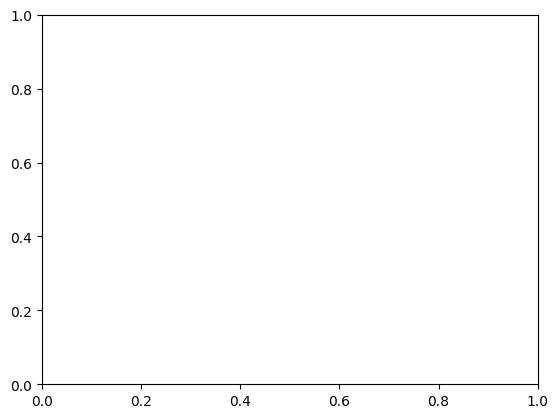

In [2]:
import matplotlib.pyplot as plt
import numpy as np
#from scipy.integrate import solve_ivp
import ipywidgets as widgets
from IPython.display import display

dt = 1e-3
t = np.arange(0,100,dt)
#N_sol = [0] #N_0 initial population
N = np.linspace(-10,200,100)

def dNdt(N,r,K,h):
    """
    Return the logisitc growth differential function for population size N with intrinsic growth rate r and carrying capacity K.
    """
    return (r*N*(1-(N/K)))-h

plt.ioff()  # stop the figure from auto-displaying when created

# set up plot
fig, ax = plt.subplots()
line, = ax.plot(N, dNdt(N,r,K,h))
ax.grid(True)

def update(change):
    line.set_ydatat(dNdt(N,change.new,100,10))
    fig.canvas.draw()

# @widgets.interact(r=(0,1,0.1), K=(0.1,100,1), h=(0,200,1), N0 = (0,200,1))
# def update(r = 1, K = 100, h = 0, N0 = 10):
    
#     """Remove old lines from plot and plot new one"""
#     [l.remove() for l in ax1.lines]
#     [l.remove() for l in ax2.lines]

#     N_sol = [N0]
    
#     for i in range(len(t)-1):
#         N_sol.append(N_sol[i]+dt*dNdt(N_sol[i],r,K,h)) #Forward-Euler
    
#     ax1.plot(N, dNdt(N,r,K,h), color = 'C0')
#     ax2.plot(t, N_sol, color = 'r')
#     display(fig)

harvest_func = widgets.Dropdown(
    value = 'Constant Harvesting',
    options = ['Constant Harvesting', 'Variable Harvesting', 'Restocking'],
    description = 'harvest function'
)

radiobuttons = widgets.RadioButtons(
    value='Logistic w/ harvesting', 
    options=['Logistic', 'Harvesting rate', 'Logistic w/ harvesting'], 
    description='Display graphs:'
)

r_val = widgets.FloatSlider(
    value = 1,
    min = 0.00,
    max = 1.00,
    step = 0.01,
    description = r'$r$',
    continuous_update = False,
    orientation = 'horizontal',
    readout=True,
    readout_format='.2f'  # Displays 2 decimal places
)

# K_val = widgets.IntSlider(
#     value = 100,
#     min = 1,
#     max = 100,
#     step = 1,
#     description = r'$K$',
#     continuous_update = False,
#     orientation = 'horizontal',
# )

# h_val = widgets.FloatSlider(
#     value = 1,
#     min = 0.00,
#     max = 1.00,
#     step = 0.01,
#     description = r'$h$',
#     continuous_update = False,
#     orientation = 'horizontal',
#     readout=True,
#     readout_format='.2f'  # Displays 2 decimal places
# )

# widgets.VBox(
#     [
#         harvest_func,
#         radiobuttons,
#         r_val,
#         # K_val,
#         # h_val
#     ]
# )

r_val.observe(update, 'value')
r_val

In [9]:
def choose_harvest_func(har_func):
    print(f'Choose the harvest function {har_func}')

widgets.interact(choose_harvest_func, har_func = ["Constant Harvesting", "Variable Harvesting", "Harvesting with Restocking"]);
widgets.interact(choose_harvest_func, har_func = (0,10,1)); #creates slider (start_val,end_val,step-size)
_ = widgets.interact(choose_harvest_func, har_func = True);


interactive(children=(Dropdown(description='har_func', options=('Constant Harvesting', 'Variable Harvesting', …

interactive(children=(IntSlider(value=5, description='har_func', max=10), Output()), _dom_classes=('widget-int…

interactive(children=(Checkbox(value=True, description='har_func'), Output()), _dom_classes=('widget-interact'…

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import ipywidgets as widgets
from IPython.display import display

N = np.linspace(-10,200,100)
C = np.linspace(-10,200,100)
dt = 1e-3
t = np.arange(0,100,dt)

def Lake_Victoria_Sys(C,N,r,d,K,hc,hn,alpha,beta):
    
    return [-d*N + beta*C*N -hn*N, r*C*(1-(C/K)) - alpha*C*N - hc*C]

plt.ioff()  # stop the figure from auto-displaying when created

# set up plot
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(10,5))
ax1.set_ylim([-10,50])
ax1.set_xlim([-10,200])
ax1.grid(True)
ax1.set_xlabel('Population size')
ax1.set_ylabel('Population Net Growth Rate')
ax1.set_title('Phase-line Diagram')

ax2.set_ylim([-10,50])
ax2.set_xlim([-10,200])
ax2.grid(True)
ax2.set_xlabel('Time')
ax2.set_ylabel('Population')
ax2.set_title('Population Growth function')

fig.suptitle('Nile perch & Cichlids in Lake Victoria')

@widgets.interact(r=(0,1,0.01), d=(0,1,0.01), K=(0.1,100,1), hc=(0,1,0.01), hn=(0,1,0.01), alpha = (0,1,0.01), beta = (0,1,0.01), N0 = (0,200,1), C0 = (0,200,1) )
def update(r = 1, d = 0.1,  K = 100, hc = 0.2, hn = 0.3, alpha =0.001, beta = 0.003, N0 = 10, C0 = 10):
    """Remove old lines from plot and plot new one"""
    [l.remove() for l in ax1.lines]
    [l.remove() for l in ax2.lines]

    N_sol = [N0]
    C_sol = [C0]
    
    for i in range(len(t)-1):
        N_sol.append(N_sol[i]+Lake_Victoria_Sys(C_sol[i],N_sol[i],r,d,K,hc,hn,alpha,beta)[1]) #Forward-Euler
        C_sol.append(C_sol[i]+Lake_Victoria_Sys(C_sol[i],N_sol[i],r,d,K,hc,hn,alpha,beta)[2])
    # ax1.set_ylim([-10,50])
    # ax1.set_xlim([-10,200])

    #ax1.plot(N, dNdt(N,r,K,0), 'c--')
    ax1.plot(N, Lake_Victoria_Sys(C,N,r,d,K,hc,hn,alpha,beta)[1], color = 'r')
    ax1.plot(C, Lake_Victoria_Sys(C,N,r,d,K,hc,hn,alpha,beta)[2], color = 'b')
    ax2.plot(t, N_sol, 'r')
    ax2.plot(t, C_sol, 'b')
    display(fig)

In [ ]:
def Lake_Victoria_Sys(C,N,r,d,K,hc,hn,alpha,beta):
    
    return [-d*N + beta*C*N -hn*N, r*C*(1-(C/K)) - alpha*C*N - hc*C]
test = Lake_Victoria_Sys(C,N,r,d,K,hc,hn,alpha,beta)